In [1]:
# --- ライブラリの準備 ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import torch
import torch.nn as nn
import joblib
import sentencepiece as spm
from collections import defaultdict
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split

# モデル固有のライブラリ
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from captum.attr import LayerIntegratedGradients

# 日本語フォント設定
plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False

# デバイス設定
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
# --- TF-IDFモデル読み込みのための関数定義 ---
# このセルをモデルロード(joblib.load)より前に実行してください

import MeCab
import ipadic
import re

# MeCabの初期化
chaser = MeCab.Tagger(ipadic.MECAB_ARGS)

# ★学習時と同じトークナイザ関数を定義する必要があります
def japanese_tokenizer(text):
    text = str(text)
    # URL除去
    text = re.sub(r'https?://[\w/:%#\$&\?\(\)~\.=\+\-]+', '<URL>', text)
    
    parsed = chaser.parse(text)
    words = []
    
    for line in parsed.split('\n'):
        if line == 'EOS' or line == '':
            continue
        parts = line.split('\t')
        word = parts[0]
        features = parts[1].split(',')
        
        # 名詞、動詞、形容詞、接頭詞を採用
        if features[0] in ['名詞', '動詞', '形容詞', '接頭詞']:
            # 不要なものを除外
            if features[1] in ['非自立', '代名詞', '数']:
                continue
            # 原形があれば使用
            if len(features) > 6 and features[6] != '*':
                words.append(features[6])
            else:
                words.append(word)
    return words

print("japanese_tokenizer を定義しました。TF-IDFモデルのロードが可能になります。")

japanese_tokenizer を定義しました。TF-IDFモデルのロードが可能になります。


In [ ]:
# --- 分析設定とパス解決 ---

# ==========================================
# ★ 1. 分析したいモデルの種類を選択
# ==========================================
# "TFIDF", "LSTM", "BERT" のいずれかを入力
MODEL_TYPE = "BERT" 

# ==========================================
# ★ 2. 対象ジャンルの設定
# ==========================================
# 特定ジャンルの場合はIDを指定
TARGET_GENRE_ID = None

# ==========================================
# ★ 3. BERT用のチェックポイント設定
# ==========================================
# ジャンルID (または 'all') ごとのcheckpoint番号
bert_checkpoints = {
    'all': 3000,
    101: 1500,
    102: 1500,
    201: 1500,
    202: 1500,
    301: 879,
    302: 1500,
    303: 774,
    304: 1059,
    305: 1299,
    306: 975,
    307: 1362,
    401: 363,
    402: 342,
    403: 1128,
    404: 234,
    9901: 354,
    9902: 258,
    9903: 792,
    9904: 48,
    9999: 1233,
    9801: 1500
}

# ==========================================
# ★ 4. LSTMモデルのパラメータ設定
# ==========================================
LSTM_EMBED_DIM = 100   # 学習コードの EMBEDDING_DIM
LSTM_HIDDEN_DIM = 128  # 学習コードの HIDDEN_DIM
LSTM_LAYERS = 1        # 指定がなかったためデフォルトの1
LSTM_PADDING_IDX = 0   # 学習コードの PADDING_IDX

# ==========================================
# ★ 5. その他設定
# ==========================================
NUM_SAMPLES = 1000  # 分析に使うデータ数（全データなら len(df) など）
CSV_PATH = 'dataset/narou_dataset.csv'

# ジャンルマップ
genres_map = {
    0: '未設定',
    101: '異世界（恋愛）', 102: '現実世界（恋愛）',
    201: 'ハイファンタジー', 202: 'ローファンタジー',
    301: '純文学', 302: 'ヒューマンドラマ', 303: '歴史',
    304: '推理', 305: 'ホラー', 306: 'アクション', 307: 'コメディー',
    401: 'VRゲーム', 402: '宇宙', 403: '空想科学', 404: 'パニック',
    9901: '童話', 9902: '詩', 9903: 'エッセイ', 9904: 'リプレイ',
    9999: 'その他', 9801: 'ノンジャンル'
}

# --- パスと名前の決定ロジック ---
if TARGET_GENRE_ID is None:
    # 全作品モード
    genre_display_name = "all"
    
    # ファイル名に使われる接尾辞 (model_all.pkl, spm_all.modelなど)
    file_suffix = "all"
    
    # BERTのフォルダ名に使われる接尾辞 (result_all)
    bert_dir_suffix = "all"
    
else:
    # 特定ジャンルモード
    genre_display_name = genres_map.get(TARGET_GENRE_ID, '不明')
    
    # ファイル名接尾辞 (model_101.pkl, spm_101.modelなど)
    file_suffix = str(TARGET_GENRE_ID)
    
    # BERTフォルダ名接尾辞 (result_異世界（恋愛）)
    bert_dir_suffix = genre_display_name

print(f"【設定確認】")
print(f"  モデル: {MODEL_TYPE}")
print(f"  対象: {genre_display_name}")
print(f"  ファイル識別子: {file_suffix}")
print(f"  BERTフォルダ名: result_{bert_dir_suffix}")

【設定確認】
  モデル: BERT
  対象: all
  ファイル識別子: all
  BERTフォルダ名: result_all


In [4]:
# --- データ読み込み ---
df = pd.read_csv(CSV_PATH)
df['あらすじ'] = df['あらすじ'].fillna('')

# URL除去
def clean_url(text):
    return re.sub(r'https?://[\w/:%#\$&\?\(\)~\.=\+\-]+', '<URL>', str(text))
df['あらすじ'] = df['あらすじ'].apply(clean_url)

# ジャンル抽出
if TARGET_GENRE_ID is not None:
    # 特定ジャンルのみ抽出
    df_target = df[df['作品ジャンル'] == TARGET_GENRE_ID].copy()
else:
    # 全作品を使用
    df_target = df.copy()

print(f"抽出されたデータ総数: {len(df_target)}件")

# 均衡サンプリング (エタり/完結を同数にする)
df_eternal = df_target[df_target['is_eternal'] == 1]
df_complete = df_target[df_target['is_eternal'] == 0]

# 指定サンプル数、またはデータが足りない場合は最小の方に合わせる
n_samples = min(NUM_SAMPLES // 2, len(df_eternal), len(df_complete))

df_test = pd.concat([
    df_eternal.sample(n=n_samples, random_state=42),
    df_complete.sample(n=n_samples, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"分析に使用するデータ数: {len(df_test)}件 (エタり/完結 各{n_samples}件)")

抽出されたデータ総数: 537829件
分析に使用するデータ数: 1000件 (エタり/完結 各500件)


In [5]:
# --- モデルロードと分析実行 ---

word_scores = defaultdict(float)
y_preds = []
y_probs = []

# ストップワード
stop_words = [
    'の', 'に', 'は', 'を', 'が', 'と', 'て', 'で', 'た', 'も', 'な', 'だ', 'し', 'か', 'ら',
    '、', '。', '！', '？', '!', '?', '・', '…', '「', '」', '（', '）', '[CLS]', '[SEP]', '[PAD]',
    '<URL>', '―', 'ー', '〜'
]

print(f"=== {MODEL_TYPE} モデルの読み込みと分析を開始 ===")

# ---------------------------------------------------------
# A. TF-IDF モデルの場合
# ---------------------------------------------------------
if MODEL_TYPE == "TFIDF":
    # model_all.pkl または model_101.pkl
    model_path = f'result_tfidf/model_{genre_display_name}.pkl'
    
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"モデルが見つかりません: {model_path}")
    
    pipeline = joblib.load(model_path)
    print(f"TF-IDFモデルロード完了: {model_path}")
    
    # 精度評価
    X_test = df_test['あらすじ']
    y_test = df_test['is_eternal'].values
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1] # エタる確率
    
    y_preds = y_pred
    y_probs = y_prob
    
    # 重要語抽出 (Linear Model係数)
    classifier = pipeline.named_steps['clf']
    vectorizer = pipeline.named_steps['tfidf']
    feature_names = vectorizer.get_feature_names_out()
    coefs = classifier.coef_[0]
    
    for word, coef in zip(feature_names, coefs):
        word_scores[word] = coef

# ---------------------------------------------------------
# B. LSTM (Subword) モデルの場合 (Attention付き修正版)
# ---------------------------------------------------------
elif MODEL_TYPE == "LSTM":
    # 1. SPMモデルロード
    spm_path = f'result_subword/spm_{file_suffix}.model'
    sp = spm.SentencePieceProcessor()
    if not sp.Load(spm_path):
        raise FileNotFoundError(f"SPMモデルが見つかりません: {spm_path}")
    print(f"SPMモデルロード完了: {spm_path}")
    
    # 2. モデル定義 (Attention付き)
    class LSTMAttentionClassifier(nn.Module):
        def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, padding_idx):
            super(LSTMAttentionClassifier, self).__init__()
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
            self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
            # Attention用の層
            self.attention = nn.Linear(hidden_dim * 2, 1)
            self.fc = nn.Linear(hidden_dim * 2, output_dim)
            self.sigmoid = nn.Sigmoid()
            
        def forward(self, text):
            embedded = self.embedding(text)
            # lstm_out: [batch, seq_len, hidden*2]
            lstm_out, _ = self.lstm(embedded)
            
            # Attentionスコアの計算
            attn_weights = torch.tanh(self.attention(lstm_out)) # [batch, seq_len, 1]
            # マスク処理などは学習時に行われていなければ省略（パディング部分は学習済みembeddingで対応）
            attn_weights = torch.softmax(attn_weights, dim=1)   # 確率分布に変換
            
            # 重み付き和を計算（Context Vector）
            context = torch.sum(attn_weights * lstm_out, dim=1) # [batch, hidden*2]
            
            return self.sigmoid(self.fc(context))

    # 3. モデルロード
    vocab_size = sp.GetPieceSize()
    # 学習時は OUTPUT_DIM = 1 でした
    model = LSTMAttentionClassifier(vocab_size, LSTM_EMBED_DIM, LSTM_HIDDEN_DIM, 1, LSTM_PADDING_IDX)
    
    lstm_path = f'result_subword/model_{file_suffix}.pt'
    if not os.path.exists(lstm_path):
         lstm_path = f'result_subword/model_{file_suffix}.pth'

    if os.path.exists(lstm_path):
        model.load_state_dict(torch.load(lstm_path, map_location=device))
        model.to(device)
        model.eval()
        print(f"LSTM(Attention)モデルロード完了: {lstm_path}")
    else:
        raise FileNotFoundError(f"LSTMモデルファイルが見つかりません: result_subword/model_{file_suffix}.pt")

    # 4. Captum設定
    # モデル出力が [batch, 1] の確率値なので、そのまま返します
    def lstm_predict(inputs):
        return model(inputs)
        
    lig = LayerIntegratedGradients(lstm_predict, model.embedding)

    # 5. ループ処理
    print("LSTM分析実行中...")
    y_test = df_test['is_eternal'].values
    
    for text in tqdm(df_test['あらすじ']):
        ids = sp.EncodeAsIds(text)
        if len(ids) == 0: ids = [0]
        input_tensor = torch.tensor([ids], dtype=torch.long).to(device)
        
        # 予測
        with torch.no_grad():
            output = model(input_tensor) # shape [1, 1] (0.0~1.0)
            prob = output.item()
            
            # 0.5以上なら「エタる(1)」
            pred = 1 if prob >= 0.5 else 0
            
            y_preds.append(pred)
            y_probs.append(prob)
            
        # Captum (勾配計算)
        # ★修正: LSTMのevalモードでの勾配計算エラーを回避するため、一時的にCuDNNを無効化
        with torch.backends.cudnn.flags(enabled=False):
            attributions = lig.attribute(inputs=input_tensor, target=0, internal_batch_size=1)
        
        attr_sum = attributions.sum(dim=2).squeeze(0).cpu().detach().numpy()
        tokens = [sp.IdToPiece(i) for i in ids]
        
        for token, score in zip(tokens, attr_sum):
            clean_token = token.replace(' ', '')
            if clean_token not in stop_words and len(clean_token) > 0:
                word_scores[clean_token] += score

# ---------------------------------------------------------
# C. BERT モデルの場合
# ---------------------------------------------------------
elif MODEL_TYPE == "BERT":
    # 1. チェックポイント番号の取得
    if TARGET_GENRE_ID is None:
        chk_num = bert_checkpoints.get('all', 3000) # デフォルト3000
    else:
        chk_num = bert_checkpoints.get(TARGET_GENRE_ID, 300)

    # 2. パス構築 (result_all/checkpoint-3000 または result_異世界.../checkpoint-300)
    model_dir = f"result_{bert_dir_suffix}/checkpoint-{chk_num}"
    
    print(f"Loading BERT from: {model_dir}")
    
    if not os.path.exists(model_dir):
        raise FileNotFoundError(f"BERTモデルディレクトリが見つかりません: {model_dir}")

    # 3. ロード
    tokenizer = AutoTokenizer.from_pretrained("tohoku-nlp/bert-large-japanese-v2")
    try:
        model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(device)
    except:
        model = AutoModelForSequenceClassification.from_pretrained(model_dir, use_safetensors=False).to(device)
        
    model.eval()
    
    # 4. Captum設定
    def bert_predict(input_ids, attention_mask=None):
        return model(input_ids=input_ids, attention_mask=attention_mask).logits
    lig = LayerIntegratedGradients(bert_predict, model.bert.embeddings)
    
    # 5. ループ処理
    print("BERT分析実行中...")
    y_test = df_test['is_eternal'].values
    
    for text in tqdm(df_test['あらすじ']):
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        input_ids = inputs['input_ids']
        attention_mask = inputs['attention_mask']
        
        with torch.no_grad():
            logits = model(input_ids, attention_mask=attention_mask).logits
            probs = torch.softmax(logits, dim=1)
            pred = torch.argmax(probs, dim=1).item()
            y_preds.append(pred)
            y_probs.append(probs[0][1].item())
            
        attributions = lig.attribute(
            inputs=input_ids, baselines=torch.zeros_like(input_ids), target=1,
            additional_forward_args=(attention_mask, ), internal_batch_size=1
        )
        
        attr_sum = attributions.sum(dim=2).squeeze(0).cpu().detach().numpy()
        tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
        
        for token, score in zip(tokens, attr_sum):
            if token not in stop_words and not token.startswith('['):
                word_scores[token] += score

=== BERT モデルの読み込みと分析を開始 ===
Loading BERT from: result_all/checkpoint-3000
BERT分析実行中...


  0%|          | 0/1000 [00:00<?, ?it/s]

=== BERT モデル評価結果 (Genre: all) ===
Accuracy: 0.9070
F1 Score: 0.9067

Classification Report:
              precision    recall  f1-score   support

          完結       0.90      0.91      0.91       500
         エタる       0.91      0.90      0.91       500

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



C:\Users\blast\AppData\Local\Temp\ipykernel_5436\65856995.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='累積スコア', y='単語', data=top_eternal, ax=axes[0], palette='Reds_r')
C:\Users\blast\AppData\Local\Temp\ipykernel_5436\65856995.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='累積スコア', y='単語', data=top_complete, ax=axes[1], palette='Blues_r')


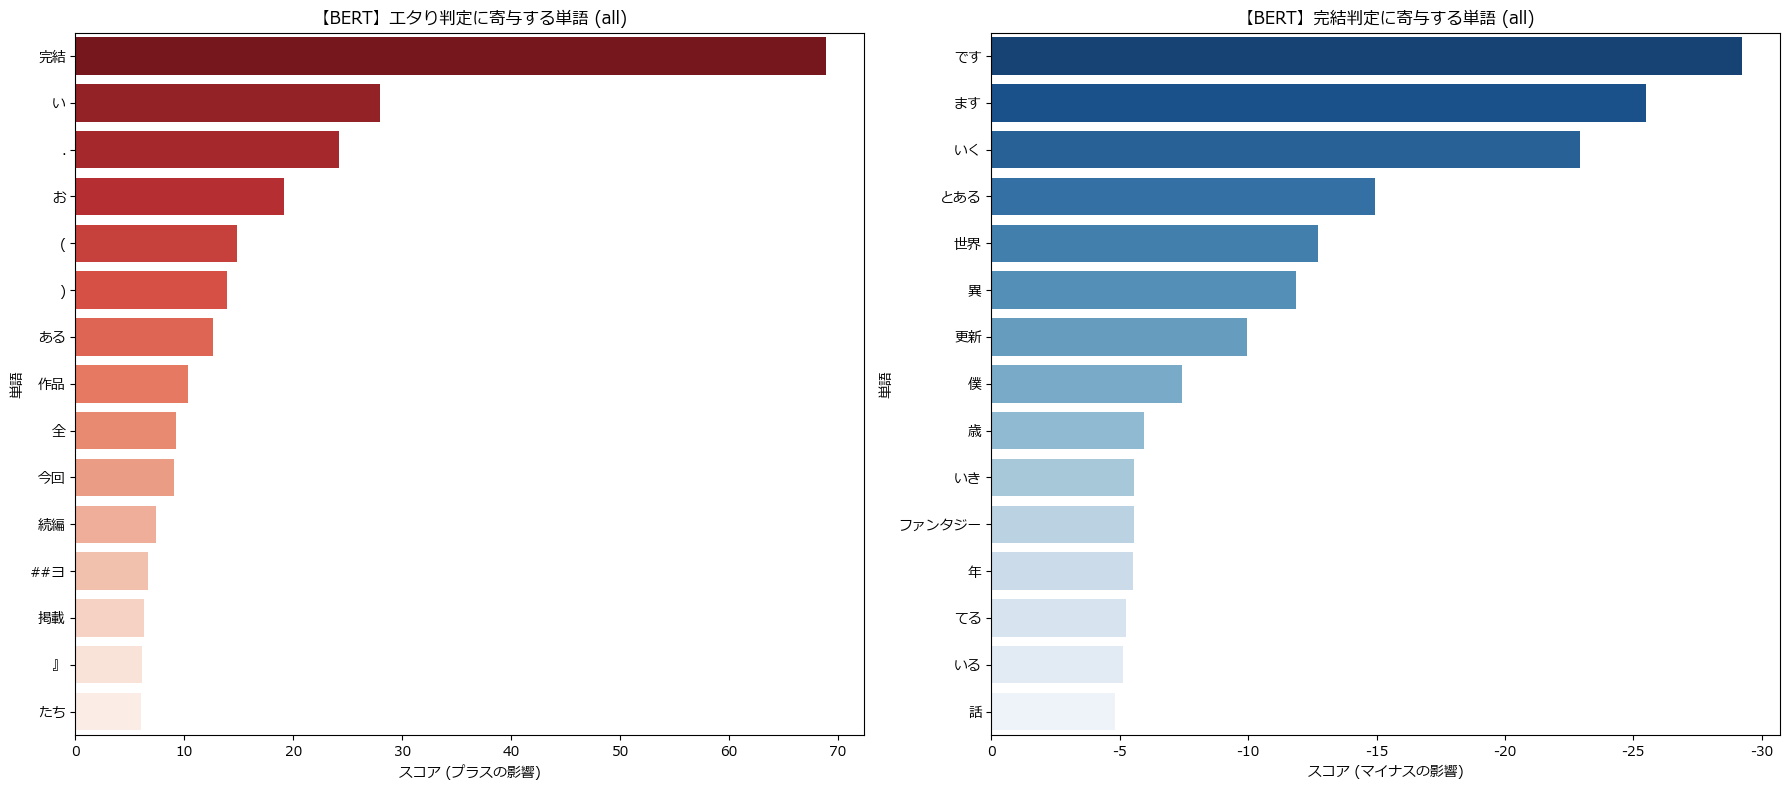

In [6]:
# --- 結果の集計と可視化 ---

# 1. モデルの精度評価
print(f"=== {MODEL_TYPE} モデル評価結果 (Genre: {genre_display_name}) ===")
acc = accuracy_score(y_test, y_preds)
f1 = f1_score(y_test, y_preds)
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_preds, target_names=['完結', 'エタる']))

# 2. 重要単語の可視化
importance_df = pd.DataFrame(word_scores.items(), columns=['単語', '累積スコア'])

# 上位・下位の抽出
top_eternal = importance_df.sort_values('累積スコア', ascending=False).head(15)
top_complete = importance_df.sort_values('累積スコア', ascending=True).head(15)

# グラフ描画
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# エタる要因
sns.barplot(x='累積スコア', y='単語', data=top_eternal, ax=axes[0], palette='Reds_r')
axes[0].set_title(f'【{MODEL_TYPE}】エタり判定に寄与する単語 ({genre_display_name})')
axes[0].set_xlabel('スコア (プラスの影響)')

# 完結要因
sns.barplot(x='累積スコア', y='単語', data=top_complete, ax=axes[1], palette='Blues_r')
axes[1].set_title(f'【{MODEL_TYPE}】完結判定に寄与する単語 ({genre_display_name})')
axes[1].set_xlabel('スコア (マイナスの影響)')
axes[1].invert_xaxis() 

plt.tight_layout()
plt.show()

# acc.txtの末尾にこのセルの出力をそのまま追加
with open('acc.txt', 'a', encoding='utf-8') as f:
    f.write(f"=== {MODEL_TYPE} モデル評価結果 (Genre: {genre_display_name}) ===\n")
    f.write(f"Accuracy: {acc:.3f}\n")
    f.write(f"F1 Score: {f1:.3f}\n")
    f.write("\nClassification Report:\n")
    f.write(classification_report(y_test, y_preds, target_names=['完結', 'エタる'],digits=3))
    f.write("\n")

In [7]:
#エタり判定の単語とスコアのTop15を表示
print("\nエタり判定に寄与する単語トップ15:")
print(top_eternal.to_string(index=False))

#完結判定の単語とスコアのTop15を表示
print("\n完結判定に寄与する単語トップ15:")
print(top_complete.to_string(index=False))


エタり判定に寄与する単語トップ15:
 単語     累積スコア
 完結 68.926285
  い 27.930344
  . 24.179073
  お 19.176854
  ( 14.846308
  ) 13.919150
 ある 12.630728
 作品 10.366248
  全  9.241767
 今回  9.011095
 続編  7.362276
##ヨ  6.638907
 掲載  6.269407
  』  6.089832
 たち  6.059897

完結判定に寄与する単語トップ15:
    単語      累積スコア
    です -29.256190
    ます -25.493031
    いく -22.927850
   とある -14.939628
    世界 -12.711744
     異 -11.865118
    更新  -9.959574
     僕  -7.403648
     歳  -5.931303
    いき  -5.569124
ファンタジー  -5.537233
     年  -5.511809
    てる  -5.245703
    いる  -5.138557
     話  -4.826484
